<a href="https://colab.research.google.com/github/gaurizendekar/Data_Science_labs/blob/main/Exp1_Intro_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment No. 1
Title: Introduction to Keras

Aim: To implement a simple neural network using Keras for digit classification.

Software Required: Python, TensorFlow, Keras, NumPy, Matplotlib, Scikit-learn

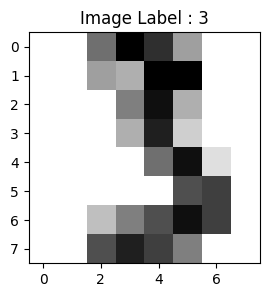

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5630 - loss: 1.5401 - val_accuracy: 0.8542 - val_loss: 0.8436
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9041 - loss: 0.5306 - val_accuracy: 0.9236 - val_loss: 0.3941
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9559 - loss: 0.2523 - val_accuracy: 0.9306 - val_loss: 0.2610
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9698 - loss: 0.1577 - val_accuracy: 0.9375 - val_loss: 0.2394
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9799 - loss: 0.1108 - val_accuracy: 0.9444 - val_loss: 0.2002
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9876 - loss: 0.0822 - val_accuracy: 0.9444 - val_loss: 0.1814
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9915 - loss: 0.0624 - val_accuracy: 0.9444 - val_loss: 0.1745
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9954 - loss: 0.0494 - val_accuracy: 0.9444 - val_loss:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load dataset
digits = load_digits()

# Display sample image
sample_index = 45

plt.figure(figsize=(3,3))
plt.imshow(
    digits.images[sample_index],
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)

plt.title("Image Label : %d" % digits.target[sample_index])
plt.show()

# Prepare data
data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)

# Normalize data
scaler = preprocessing.StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One Hot Encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Build Model
model = Sequential([
    Input(shape=(64,)),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    Y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)